In [1]:
%load_ext autoreload
%autoreload 2

from scripts.lattice import *
from scripts.scba import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *
from triqs.lattice.tight_binding import dos

dim = 3
save_dir = f'data/{dim}d/rpa_ba'

Starting serial run at: 2026-05-11 14:29:26.707139


Gamma =  0.1


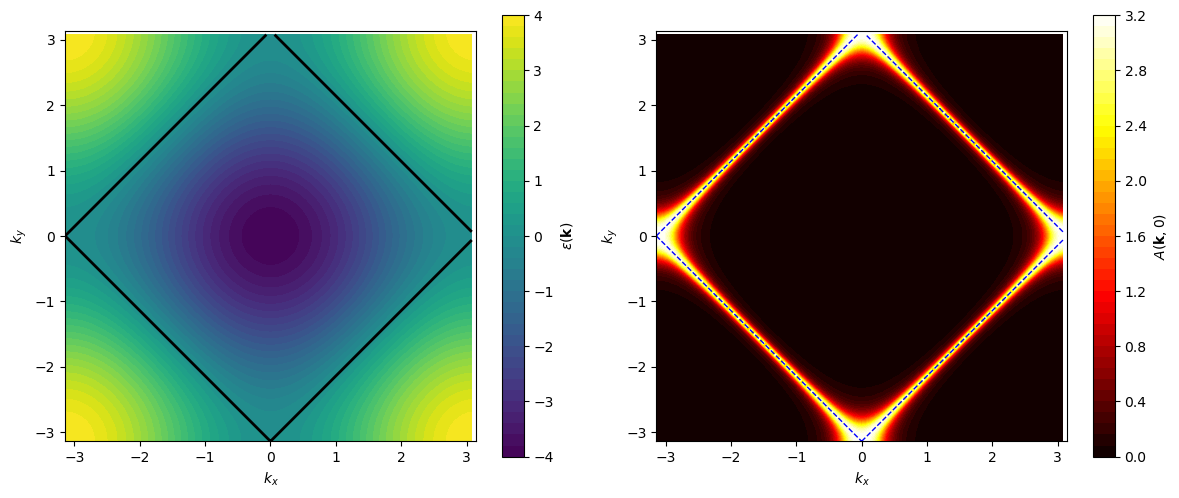

In [2]:
square = LATTICE(dim=2, tp=0.)
nk = 100

square.get_e_k(nk)
eps = square.e_k.data[:, 0, 0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi


v = 1
rho = dos(square.H_r.tb, nk, n_eps=100, name='')[0]
rho_0 = np.interp(0.0, rho.eps, rho.rho)
Gamma = np.pi * v**2 * rho_0
Gamma = 0.1
print('Gamma = ', Gamma)

T = 0.1
n = 1
mu = get_mu(e_k=square.e_k, n_goal=n, beta=1/T)
Ak0 = (1/np.pi) * Gamma / (Gamma**2 + (eps - mu)**2)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
cf = ax.contourf(kx, ky, eps, levels=50)
plt.colorbar(cf, ax=ax, label=r'$\varepsilon(\mathbf{k})$')
ax.contour(kx, ky, eps, levels=[mu], colors='black', linewidths=2)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

ax = axes[1]
cf2 = ax.contourf(kx, ky, Ak0, levels=50, cmap='hot')
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

[Parallel(n_jobs=11)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done   2 out of  11 | elapsed:  6.1min remaining: 27.4min
[Parallel(n_jobs=11)]: Done   4 out of  11 | elapsed:  6.6min remaining: 11.6min
[Parallel(n_jobs=11)]: Done   6 out of  11 | elapsed:  6.7min remaining:  5.6min
[Parallel(n_jobs=11)]: Done   8 out of  11 | elapsed:  6.7min remaining:  2.5min
[Parallel(n_jobs=11)]: Done  11 out of  11 | elapsed:  7.8min finished


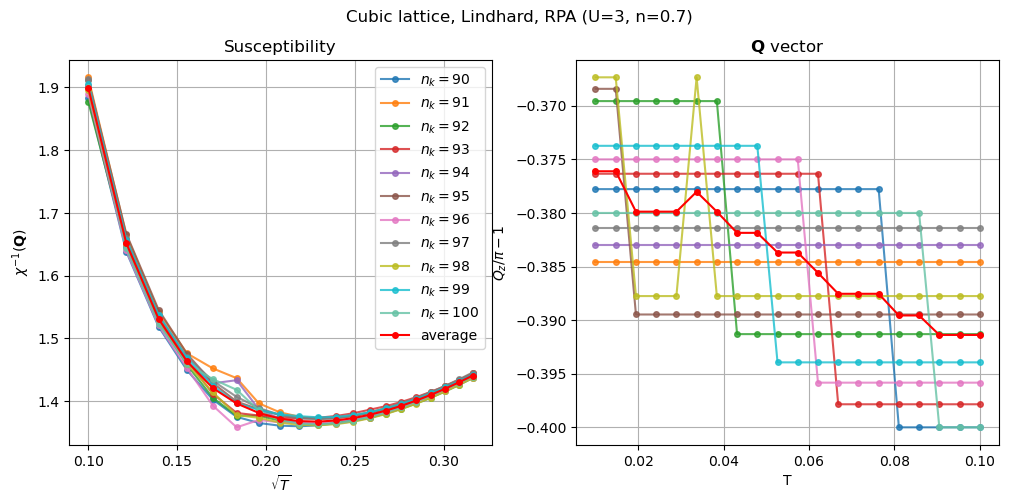

In [24]:
U = 3
n = 0.7
T_list = np.linspace(0.01, 0.1, 20)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Lindhard, RPA (U={U}, n={n})'

Gamma = 0.1
nk_list = list(range(90, 101, 1))
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'S_iwk_list': -1.j*Gamma, 'n_iw': 128, 'method': 'matsubara_fft'} for nk in nk_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=11)

results_avg = results_list[-1].copy()
results_avg['invchi'] = sum([results['invchi'] for results in results_list])/len(results_list)
results_avg['Q'] = sum([results['Q'] for results in results_list])/len(results_list)

fig = None
for results in results_list:
    nk = results['nk']
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=0.5,
                        title=title, label=f'$n_k={nk}$', figure=fig, alpha=0.8)
    
fig, _ = pcut_chi(results_avg, 'T', plot_Q=(0,0,1), fit=False, x_exp=0.5,
                    title=title, label=f'average', figure=fig, color='red')

plt.show()

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


Starting serial run at: 2026-05-11 15:47:47.546783
Starting serial run at: 2026-05-11 15:47:47.547078
Starting serial run at: 2026-05-11 15:47:47.551900


Starting serial run at: 2026-05-11 15:47:47.586764
Starting serial run at: 2026-05-11 15:47:47.598231
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:  1.8min remaining:  2.8min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:  1.9min remaining:  1.2min


n = 0.6 : ampl = 3.8334756925689395, exp = 0.87184892219664, Tc = -0.2718355582395332
n = 0.65 : ampl = 3.6513883908907108, exp = 0.8905713330839673, Tc = -0.23268048608942674
n = 0.7 : ampl = 3.1707841667769805, exp = 0.8303482713115931, Tc = -0.16630748766371042
n = 0.75 : ampl = 2.5818372257719866, exp = 0.7207180078009289, Tc = -0.07569594320033354
n = 0.8 : ampl = 2.4800337197908013, exp = 0.7835232446395843, Tc = -0.03456925577825657


[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  1.9min finished


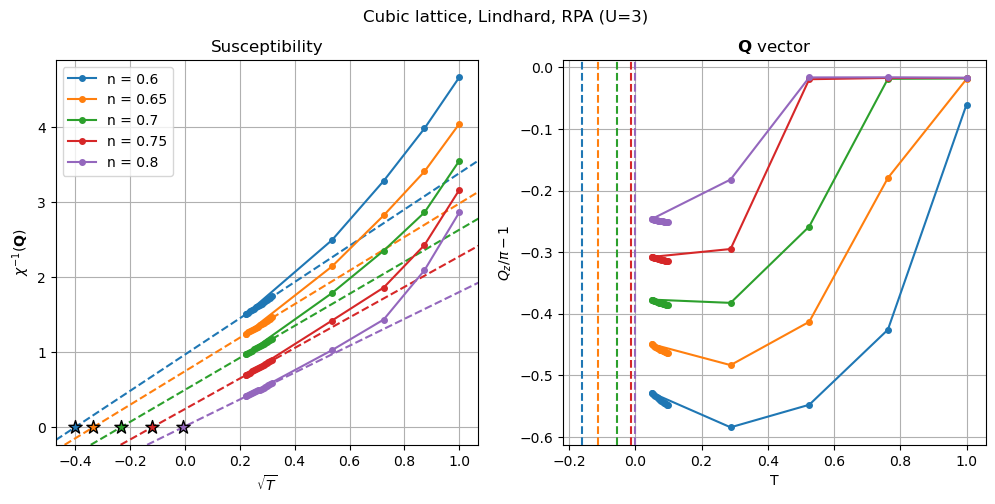

In [26]:
U = 3
n_list = np.linspace(0.6, 0.8, 5)
T_list = np.concatenate([np.linspace(0.05, 0.1, 15), np.linspace(0.05, 1., 5)])
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 100
Gamma = 0.05
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'S_iwk_list': -1.j*Gamma, 'fit': True, 'method': 'lindhard2'} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=5)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc = results['Xc']
    ampl = results['ampl']
    gamma = results['gamma']
    print(f"n = {n} : ampl = {ampl}, exp = {gamma}, Tc = {Tc}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=0.5, fit=True,
                        title=title, label=f'n = {n}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    axs[0].scatter(-fit[1]/fit[0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.6s finished


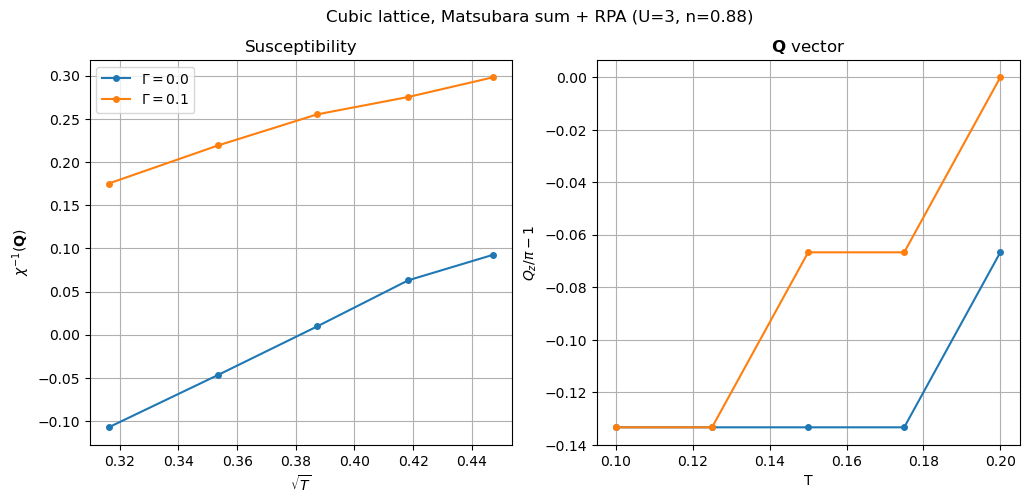

In [19]:
U = 3
n = 0.88
T_list = np.linspace(0.1, 0.2, 5)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Matsubara sum + RPA (U={U}, n={n})'

nk = 30

Gamma_list = [0., 0.1]
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'S_iwk_list': -1.j*Gamma, 'method': 'matsubara_fft', 'n_iw': 128, 'n_iw_extr': True} for Gamma in Gamma_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=2)

fig = None
for i, results in enumerate(results_list):
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=0.5, title=title, label=f'$\Gamma={Gamma_list[i]}$', figure=fig)

plt.show()

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:    4.9s
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:    9.1s remaining:    9.1s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:  4.3min finished


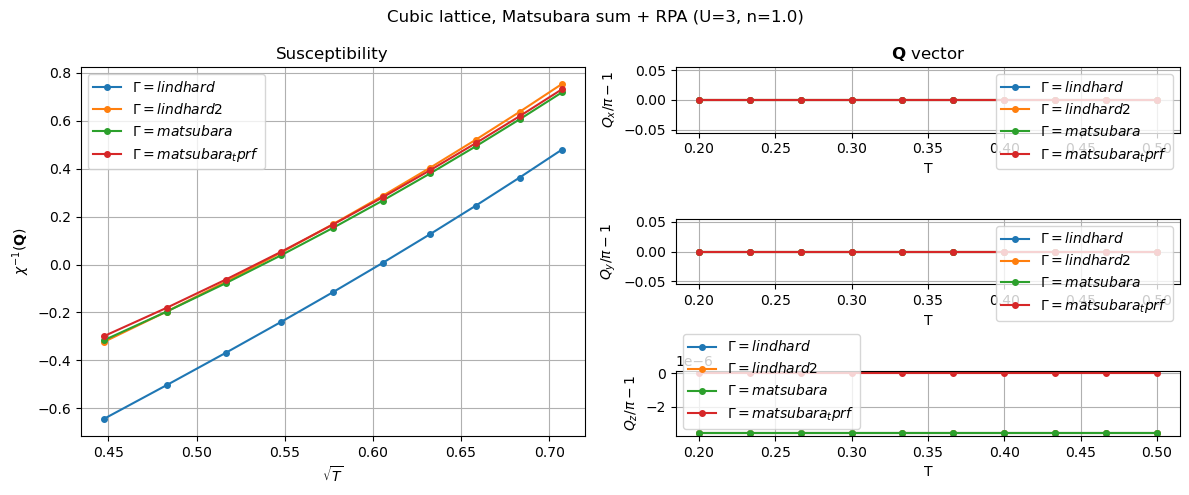

In [5]:
U = 3
n = 1.
T_list = np.linspace(0.2, 0.5, 10)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Matsubara sum + RPA (U={U}, n={n})'

nk = 50
Gamma = 0.1

method_list = ['lindhard', 'lindhard2', 'matsubara', 'matsubara_tprf']
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'S_iwk_list': [[-1j*Gamma]*256]*len(T_list), 'nk_avg': (1,1), 'method': method, 'n_iw_extr': True, 'refine': True} for method in method_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=4)

fig = None
for i, results in enumerate(results_list):
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=0.5, title=title, label=f'$\Gamma={method_list[i]}$', figure=fig)

plt.show()

In [ ]:
U = 3
n = 0.88
T_list = np.linspace(0.05, 0.2, 5)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Matsubara sum + RPA (U={U}, n={n})'

nk = 30

Gamma_list = [0.]
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'S_iwk_list': [[-1j*Gamma]*256]*len(T_list), 'nk_avg': (1,1), 'method': 'matsubara', 'n_iw_extr': False, 'refine': True} for Gamma in Gamma_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=2)

fig = None
for i, results in enumerate(results_list):
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=0.5, title=title, label=f'lindhard (marios notes)', figure=fig)

plt.show()

In [ ]:
U = 3
n = 0.88
T_list = np.linspace(0.05, 0.2, 5)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Matsubara sum + RPA (U={U}, n={n})'

nk = 30

Gamma_list = [0.]
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'S_iwk_list': [[-1j*Gamma]*256]*len(T_list), 'nk_avg': (1,1), 'method': 'lindhard', 'n_iw_extr': False, 'refine': True} for Gamma in Gamma_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=2)

fig = None
for i, results in enumerate(results_list):
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=0.5, title=title, label=f'tprf Matsubara sum', figure=fig)

plt.show()

In [2]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0.1, 0.3, 10)

nk = 15

Gamma_list = [0., 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.3f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')

    par_list = []
    for j, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[j], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'nk_avg': (10,1), 
                   'S_iwk_list': [1j*Gamma_list[i] for _ in T_list]} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=1, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

: 

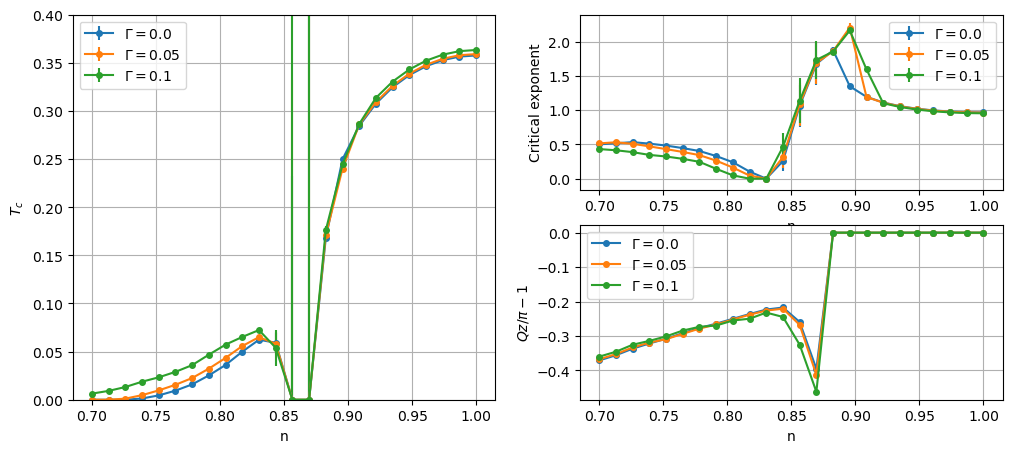

In [6]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(0., 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

Gamma_list = [0., 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.3f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"$\Gamma={Gamma}$", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"$\Gamma={Gamma}$", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"$\Gamma={Gamma}$", markersize=4)

    color = line[0].get_color()
    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        #a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

    for a in ax:
        a.legend()

plt.show()

In [38]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.05, 6)

nk = 100

Gamma = 0.025
tp_list = [0.05, 0.1]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.3f}tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')

    par_list = []
    for j, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[j], 0.005)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'nk_avg': (10,1), 'tp': tp,
                   'S_iwk_list': [1j*Gamma for _ in T_list]} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
Starting serial run at: 2026-04-27 11:32:19.460754
Starting serial run at: 2026-04-27 11:32:19.460862
Starting serial run at: 2026-04-27 11:32:19.476135


Starting serial run at: 2026-04-27 11:32:19.517090
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  5.5min


Starting serial run at: 2026-04-27 11:37:48.664854


Starting serial run at: 2026-04-27 11:37:49.502659
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:  5.8min


Starting serial run at: 2026-04-27 11:43:46.625501


...

Starting serial run at: 2026-04-27 12:07:12.018905


Starting serial run at: 2026-04-27 12:07:24.946133


Starting serial run at: 2026-04-27 12:07:25.619399
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 17.2min


Starting serial run at: 2026-04-27 12:12:50.348300
[Parallel(n_jobs=6)]: Done  16 out of  24 | elapsed: 17.7min remaining:  8.9min


Starting serial run at: 2026-04-27 12:13:25.034416
[Parallel(n_jobs=6)]: Done  19 out of  24 | elapsed: 23.3min remaining:  6.1min
[Parallel(n_jobs=6)]: Done  22 out of  24 | elapsed: 23.5min remaining:  2.1min
[Parallel(n_jobs=6)]: Done  24 out of  24 | elapsed: 23.6min finished


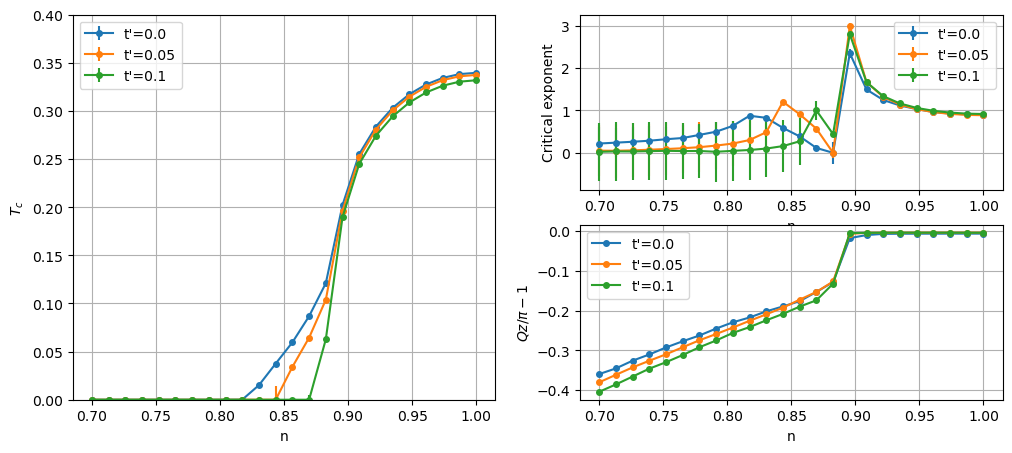

In [40]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(-0., 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

Gamma = 0.025
tp_list = [0., 0.05, 0.1]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.3f}tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"t'={tp}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        #a.axvline(n_crit, linestyle='--', color=color)
        a.legend()


plt.savefig(f'{save_dir}/g{Gamma:.3f}postp.png', dpi=100)
plt.show()

SCBA: nk=100^2, beta=10.00, mu=0.0000, scatt. pot.=1.000
Converged at step 15 with diff = 4.495e-11
0.538182094297202


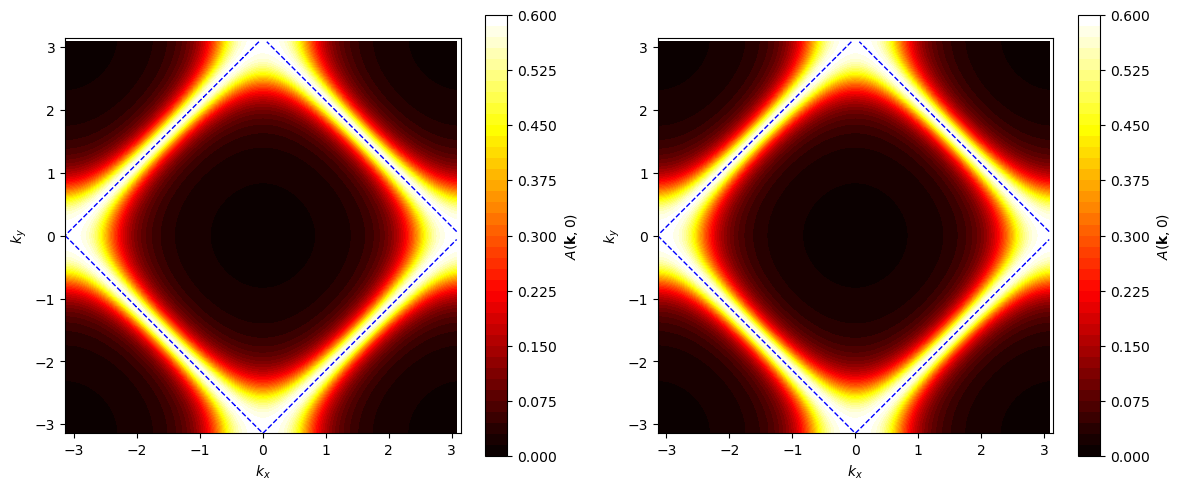

In [142]:
square = LATTICE(dim=2)
nk = 100

square.get_e_k(nk)
eps = square.e_k.data[:,0,0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

T = 0.1
n = 1
mu = get_mu(square.e_k, n, 1/T)
v = 1.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

square.get_e_k(nk=nk)
scba = SCBA(square, 1/T, nk=nk)
scba.run(v=v, n_goal=n, constant=True)
A1 = get_A_iw0k(scba.G_iwk).reshape(nk, nk)

S_iw = GfImFreq(beta=1/T, statistic='Fermion', n_points=scba.n_iw, target_shape=[1,1])
S_iw.data[:, 0, 0] = scba.S_iwk.data[:, :, 0, 0].mean(axis=1)

# Pade continue to real axis at omega=0
w_mesh = MeshReFreq(w_min=0.0, w_max=0.0, n_w=1)
S_w = GfReFreq(mesh=w_mesh, target_shape=[1,1])
S_w.set_from_pade(S_iw, n_points=60)

Gamma_eff = -S_w.data[0, 0, 0].imag
print(Gamma_eff)

A2 = (1/np.pi) * Gamma_eff / (Gamma_eff**2 + (eps - mu)**2)

vmax = max(A1.max(), A2.max())
vmin = min(A1.min(), A2.min())

ax = axes[0]
cf1 = axes[0].contourf(kx, ky, A1, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf1, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

ax = axes[1]
cf2 = axes[1].contourf(kx, ky, A2, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

SCBA: nk=100^2, beta=10.00, mu=0.0000, scatt. pot.=1.000
Converged at step 11 with diff = 4.054e-11
0.1379977548712244


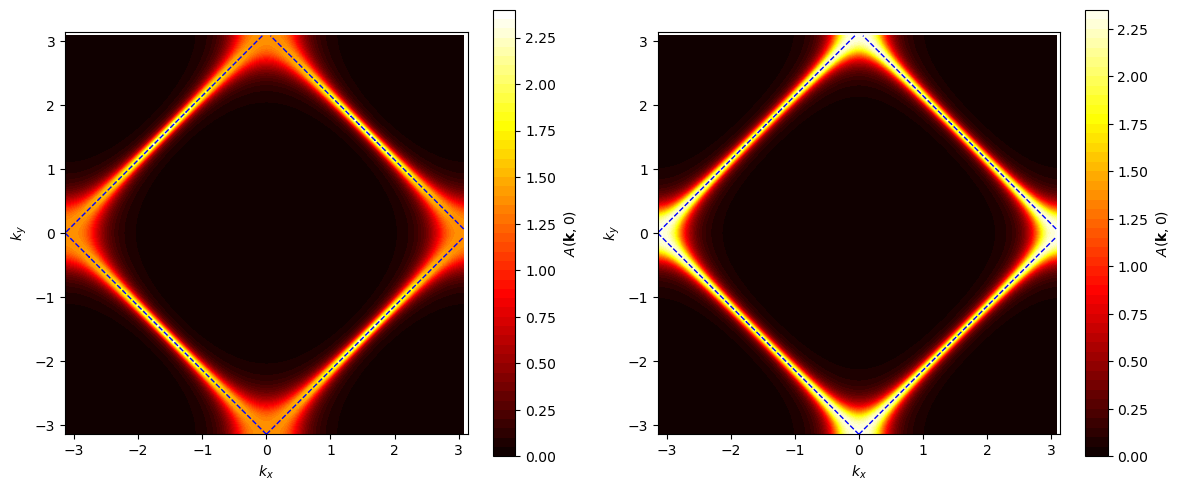

In [143]:
square = LATTICE(dim=2)
nk = 100

square.get_e_k(nk)
eps = square.e_k.data[:,0,0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

T = 0.1
n = 1
mu = get_mu(square.e_k, n, 1/T)
v = 1.
xi = 0.2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

square.get_e_k(nk=nk)
scba = SCBA(square, 1/T, xi=xi, nk=nk)
scba.run(v=v, n_goal=n, constant=False)
A1 = get_A_iw0k(scba.G_iwk).reshape(nk, nk)

S_iw = GfImFreq(beta=1/T, statistic='Fermion', n_points=scba.n_iw, target_shape=[1,1])
S_iw.data[:,0,0] = scba.S_iwk.data[:,:,0,0].mean(axis=1)

# Pade continue to real axis at omega=0
w_mesh = MeshReFreq(w_min=0.0, w_max=0.0, n_w=1)
S_w = GfReFreq(mesh=w_mesh, target_shape=[1,1])
S_w.set_from_pade(S_iw, n_points=60)

Gamma_eff = -S_w.data[0,0,0].imag
print(Gamma_eff)

A2 = (1/np.pi) * Gamma_eff / (Gamma_eff**2 + (eps - mu)**2)

vmax = max(A1.max(), A2.max())
vmin = min(A1.min(), A2.min())

ax = axes[0]
cf1 = axes[0].contourf(kx, ky, A1, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf1, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

ax = axes[1]
cf2 = axes[1].contourf(kx, ky, A2, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()